In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
using EccentricBurstTiming, CairoMakie, QuadGK, CSV
using JLD2
# using Unitful, UnitfulAstro
defaulttheme = Theme(Axis = (xgridvisible=false, ygridvisible=false,
                            yminorticks=IntervalsBetween(4),
                            xminorticks=IntervalsBetween(4),
                            yminorticksvisible=true,
                            xminorticksvisible=true,
                            titlefont = :regular,
                            xminorticksize=3,
                            yminorticksize=3,
                            ylabelsize=20,
                            xlabelsize=20
                            ),
                    Legend = (framevisible=false,),
                    size=(800, 600))
set_theme!(defaulttheme)
update_theme!(theme_latexfonts())

const EBT = EccentricBurstTiming
const DATADIR = joinpath(@__DIR__, "..", "data")

const G_solar = 3.9413556368747037e-7 # R⊙^3 s^-2 M⊙^-1
const c_solar = 0.4309220324852666 # R⊙/s

  Activating project at `~/projects/EccentricBurstTimings`


0.4309220324852666

# dt as a function of tertiary mass and distance

## for LIGO

In [4]:
function get_a_at_xHz(x, e, M)
    cbrt(G_solar*M/π*((1 + e)^1.195)^2/(x^2*(1 - e^2)^3))
end

function get_unperturbed_model(;args...)
    args = copy(args)

    if haskey(args, :m1)
        pop!(args, :m1)
    end

    if haskey(args, :m2)
        pop!(args, :m2)
    end
    args[:m3] = 0.0

    return  BurstTimingModel(;args...)
end

function get_perturbed_model(;args...)
    args = copy(args)
    
    if haskey(args, :m1)
        pop!(args, :m1)
    end

    if haskey(args, :m2)
        pop!(args, :m2)
    end

    return  BurstTimingModel(;args...)
end

function get_models(;args...)

    m = get_unperturbed_model(;args...)
    m_p =  get_perturbed_model(;args...)
    
    return m, m_p
end

get_models (generic function with 1 method)

In [23]:
function do_parameter_study(;n=15, log10_m3_min=1, log10_m3_max=2, log10_alpha_min=1, log10_alpha_max=5,
    m12=60, eta=0.25, e_in=0.9, f0=1, i0=0.0, e_out=0.0, N_bursts=50, f_match=10)
  
    log10_m3s = range(log10_m3_min, log10_m3_max, length=n)
    log10_alphas = range(log10_alpha_min, log10_alpha_max, length=n+1)

    a_in = get_a_at_xHz(f0, e_in, m12)

    dt_max = zeros(Float64, n, n+1)

    Threads.@threads for i ∈ eachindex(log10_m3s)
        m3 = 10^log10_m3s[i]
        for j ∈ eachindex(log10_alphas)
            alpha = 10^log10_alphas[j]
            a_out = alpha*a_in
            m_up, m_p = get_models(m12=m12, a0=a_in, e0=e_in, m3=m3, eta=eta, R3=a_out, i0=i0)

            try
                evolve!(m_up, 1_000_000, f_GW_max=20, e_min=0.0001, verbose=false, Rmin_threshold=Inf)
            catch e
                println(e)
                dt_max[i, j] = NaN
                continue
            end

            try
                evolve!(m_p, 1_000_000, f_GW_max=20, e_min=0.0001, verbose=false, Rmin_threshold=Inf, do_outer_orbit=true)
            catch e
                println(e)
                dt_max[i, j] = NaN
                continue
            end

            if !(EBT.peak_f_GW(m_up, length(m_up.t)) >= 10) || !(EBT.peak_f_GW(m_p, length(m_p.t)) >= 10)
                println(i, " ", j)
                continue
            end

            # t_f_match_idx = findlast(l -> EBT.peak_f_GW(m, l) <= f_match, length(m.t):-1:1)
            # t_p_f_match_idx = findlast(l -> EBT.peak_f_GW(m_p, l) <= f_match, length(m_p.t):-1:1)

            
            t_f_match_idx = findmin(l -> abs(EBT.peak_f_GW(m_up, l) - f_match), 1:length(m_up.t))[2]
            t_p_f_match_idx = findmin(l -> abs(EBT.peak_f_GW(m_p, l) - f_match), 1:length(m_p.t))[2]

            # println(EBT.peak_f_GW(m_up, t_f_match_idx))
            # println(EBT.peak_f_GW(m_p, t_p_f_match_idx))
            # println()

            # t = m.t[end - min(N_bursts, length(m.t) - 1):end]
            # t_p = m_p.t[end - min(N_bursts, length(m_p.t) - 1):end]

            # t = to_seconds(m, t .- t[end])
            # t_p = to_seconds(m_p, t_p .- t_p[end])

            t = to_seconds(m_up, m_up.t[t_f_match_idx])# - m_up.t[end])
            t_p = to_seconds(m_p, m_p.t[t_p_f_match_idx])# - m_p.t[end])

            # k = min(length(t), length(t_p))

            # dt = abs.(t[1:k] .- t_p[1:k])
            dt = abs(t - t_p)
            dt_max[i, j] = dt#maximum(dt)
        end
    end

    
    # heatmap(log10_m3s, log10_alphas, dt_max)
    return log10_m3s, log10_alphas, dt_max
end

do_parameter_study (generic function with 1 method)

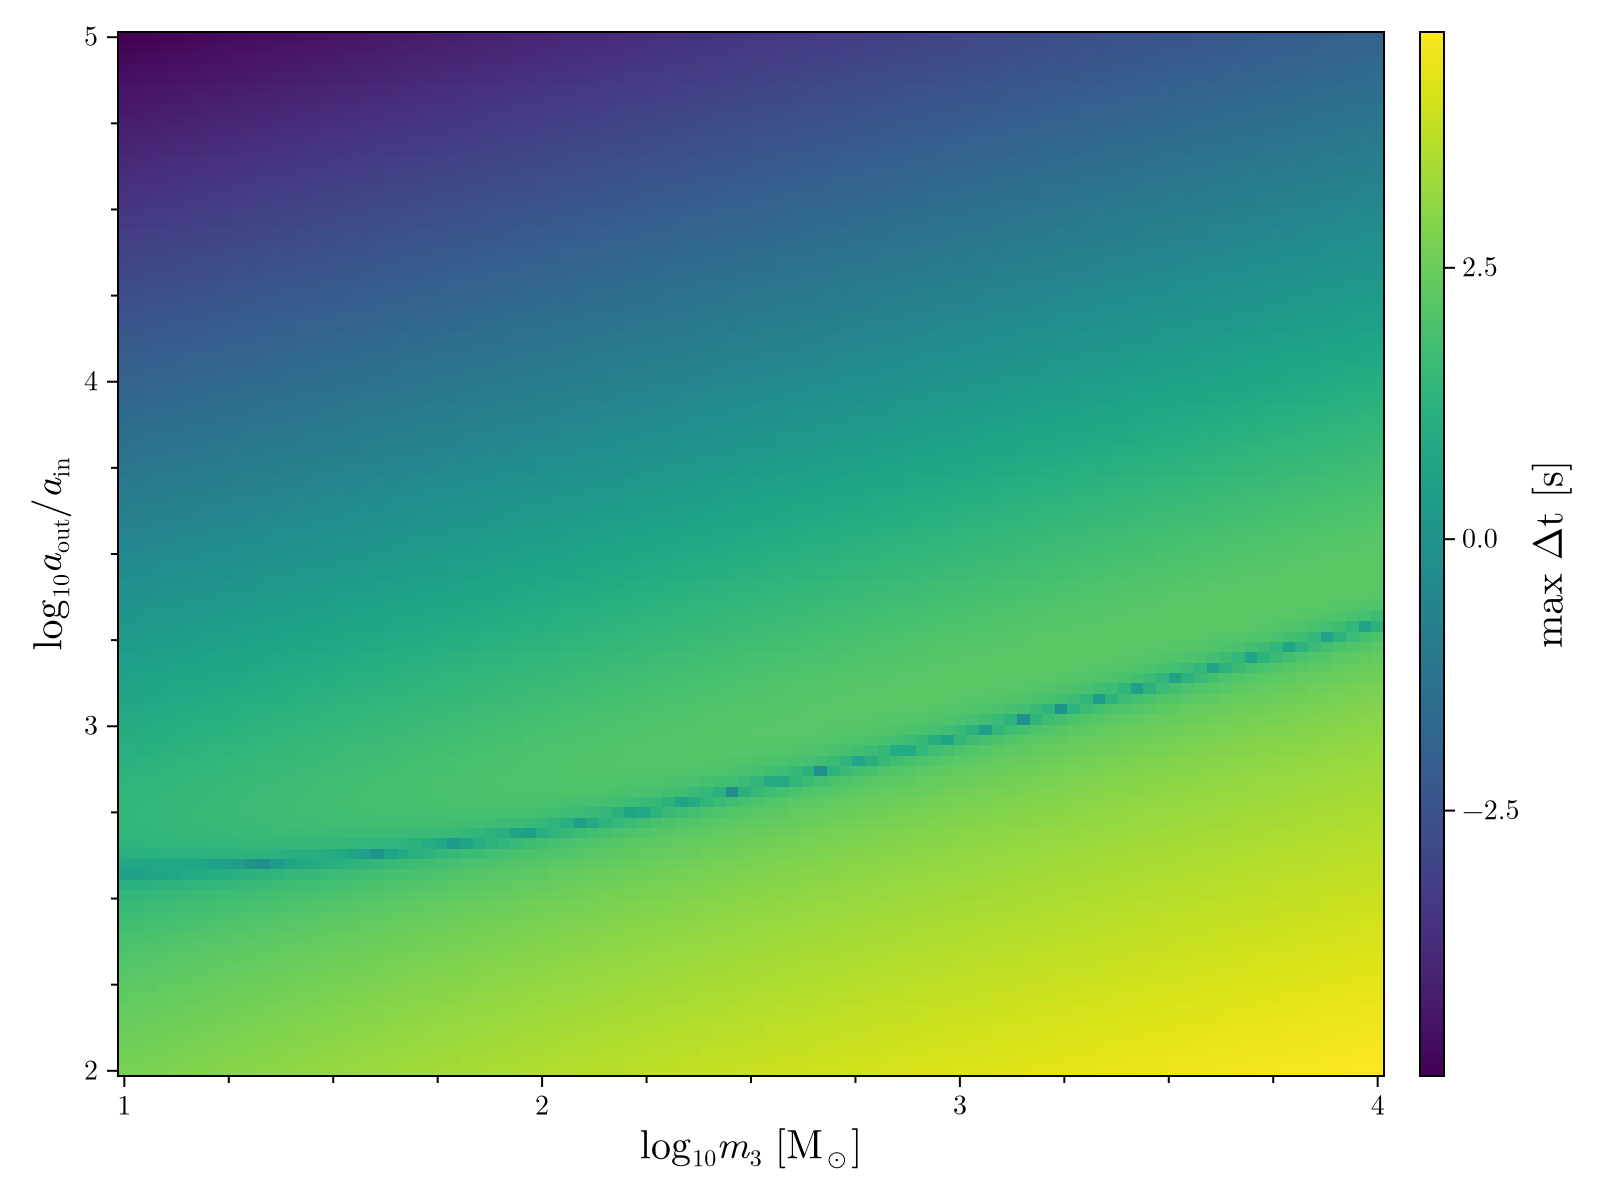

In [26]:
let
    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"\log_{10}{a_\text{out}/a_\text{in}}", xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")

    log10_m3s, log10_alphas, dt_max = do_parameter_study(n=100, log10_m3_max=4, log10_alpha_min=2, eta=0.2)
    # log10_m3s, log10_alphas, dt_max = do_parameter_study(n=10, log10_m3_min=1, log10_m3_max=2, log10_alpha_min=3.3, log10_alpha_max=4, eta=0.2)

    hm = heatmap!(log10_m3s, log10_alphas, log10.(dt_max))
    Colorbar(fig[1, 2], hm, label="max Δt [s]", labelsize=20)
    fig
end

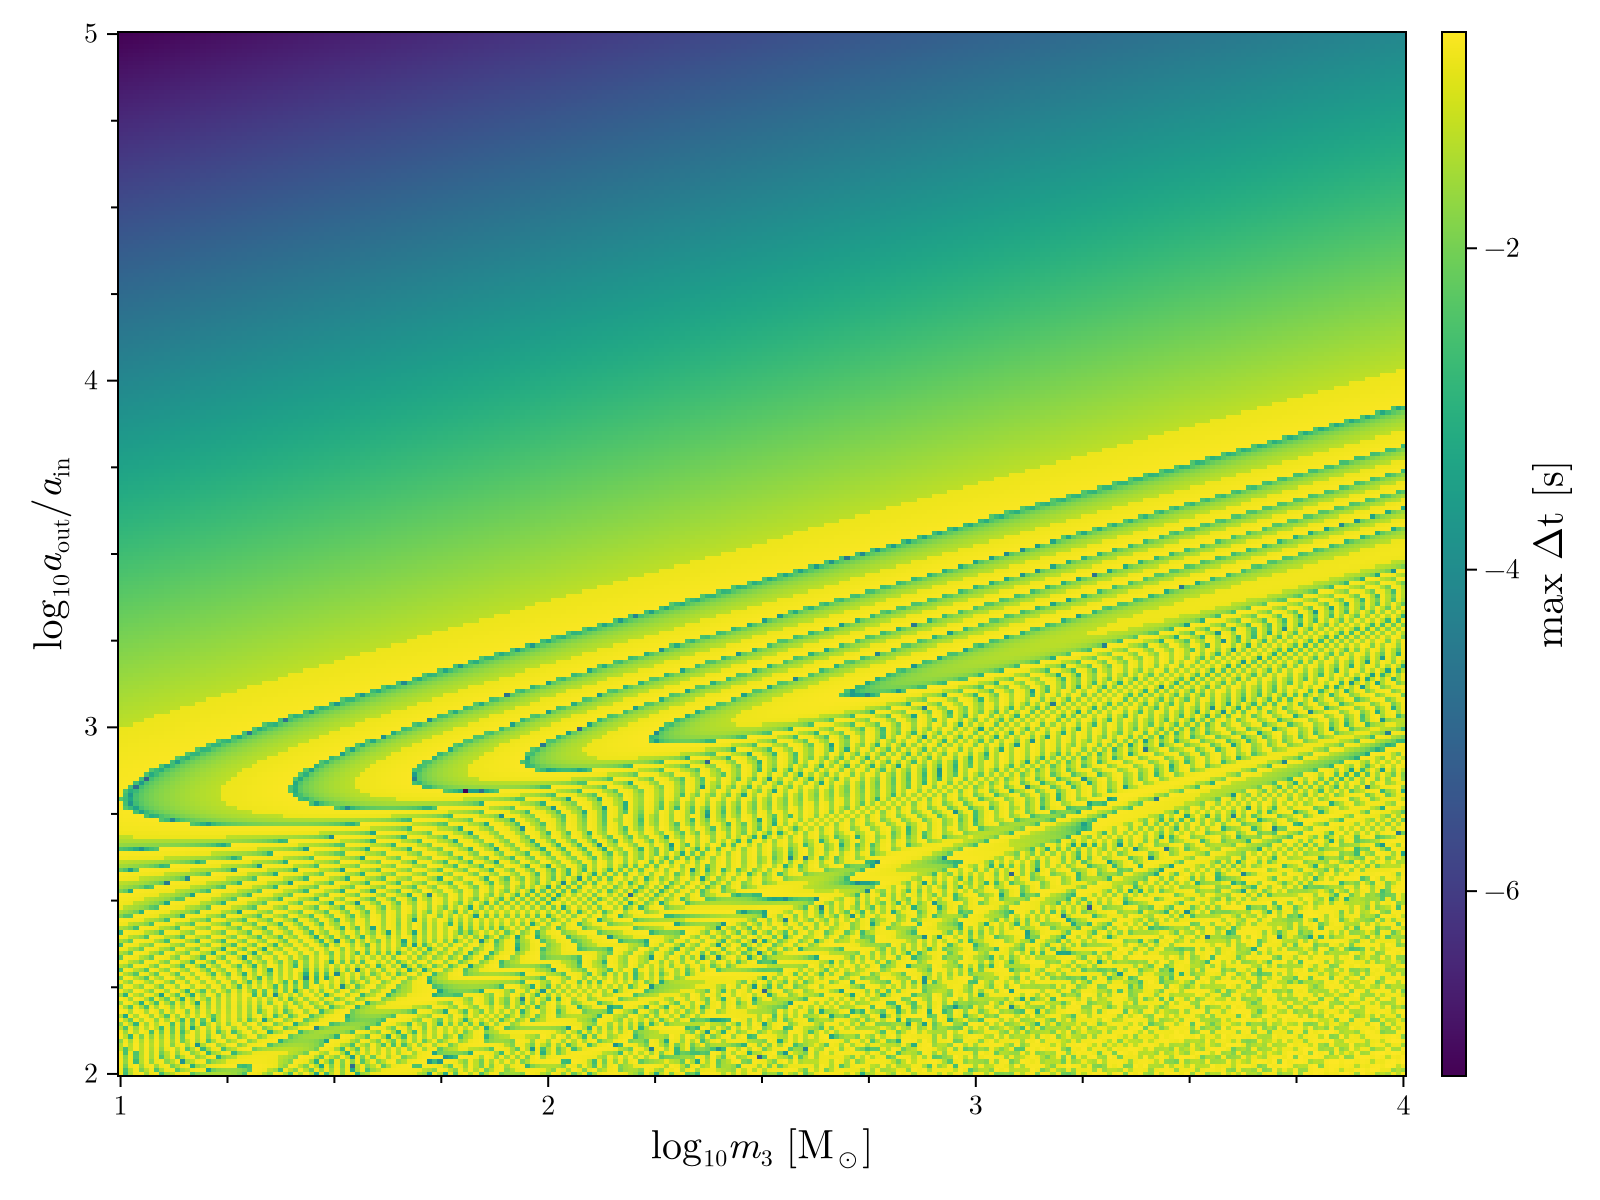

In [49]:
let
    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"\log_{10}{a_\text{out}/a_\text{in}}", xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")

    log10_m3s, log10_alphas, dt_max = do_parameter_study(n=250, log10_m3_max=4, log10_alpha_min=2, eta=0.2)
    # log10_m3s, log10_alphas, dt_max = do_parameter_study(n=10, log10_m3_min=1, log10_m3_max=2, log10_alpha_min=3.3, log10_alpha_max=4, eta=0.2)

    hm = heatmap!(log10_m3s, log10_alphas, log10.(dt_max))
    Colorbar(fig[1, 2], hm, label="max Δt [s]", labelsize=20)
    fig
end

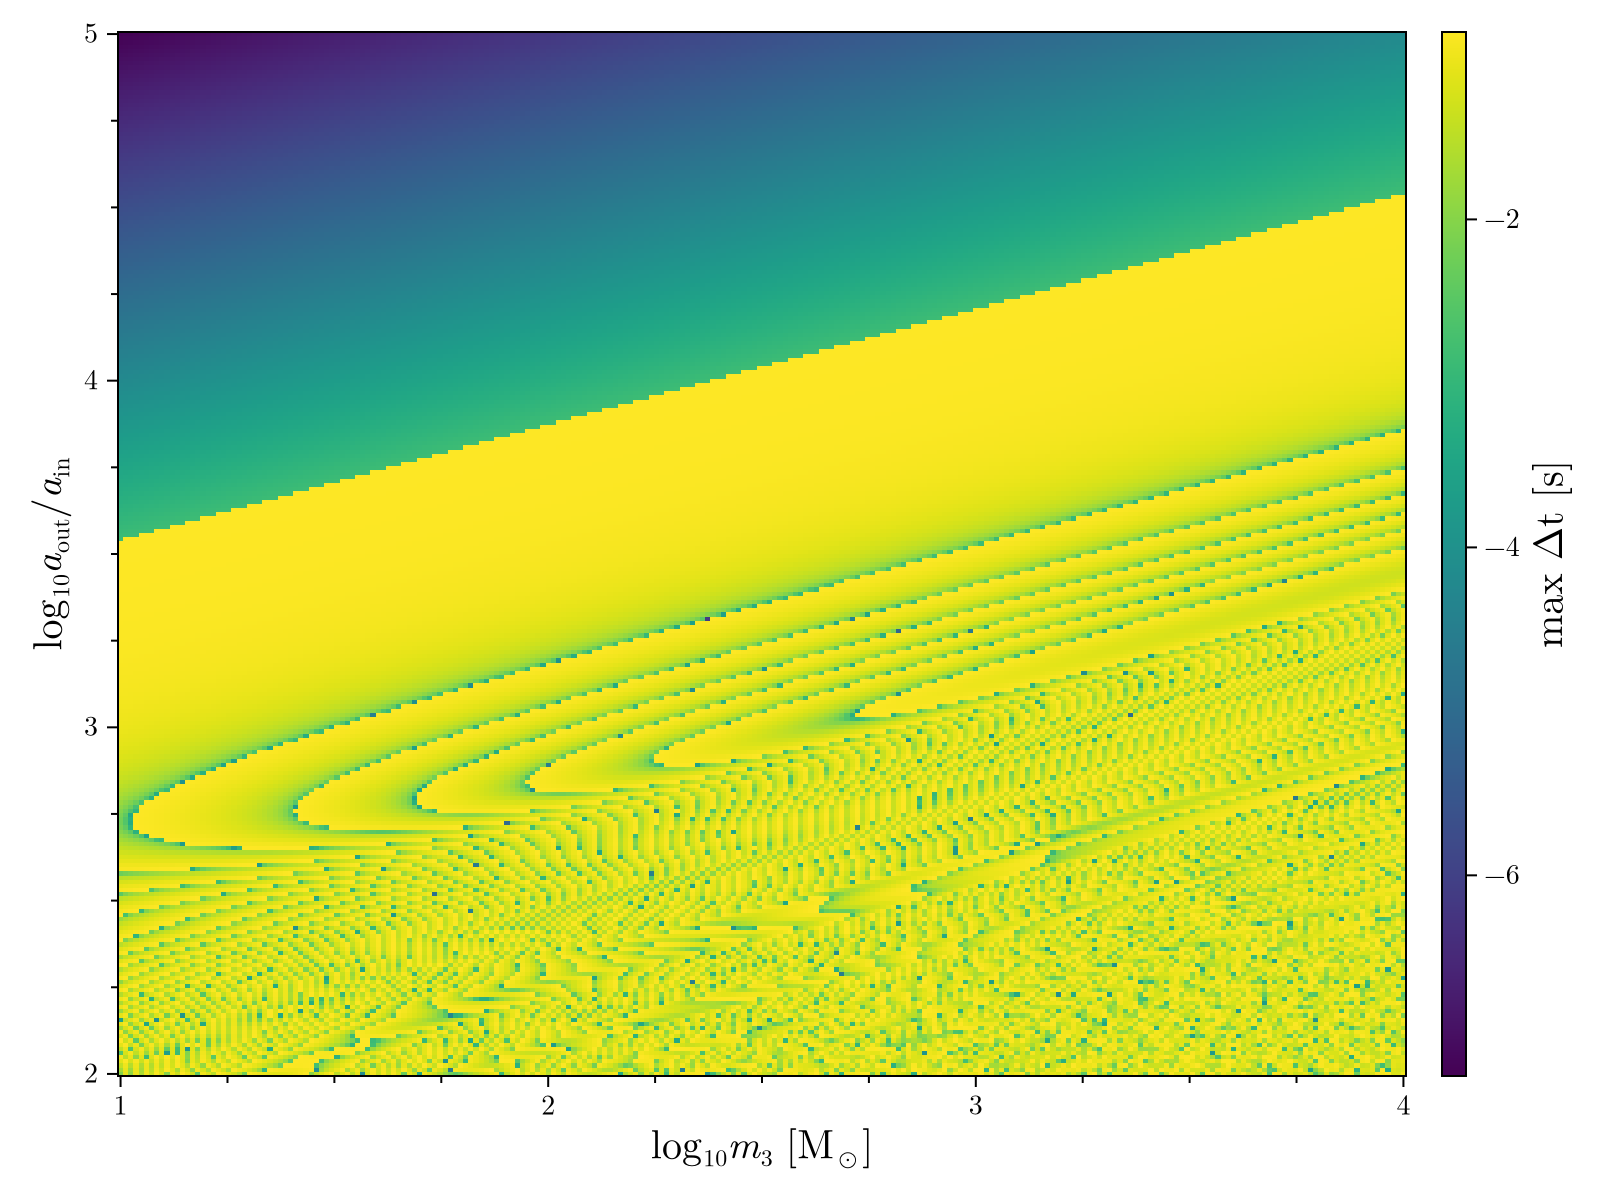

In [48]:
let
    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"\log_{10}{a_\text{out}/a_\text{in}}", xlabel=L"$\log_{10}{m_3}$ [M$_\odot$]")

    log10_m3s, log10_alphas, dt_max = do_parameter_study(n=250, log10_m3_max=4, log10_alpha_min=2)

    hm = heatmap!(log10_m3s, log10_alphas, log10.(dt_max))
    Colorbar(fig[1, 2], hm, label="max Δt [s]", labelsize=20)
    fig
end

what is the eccentricity at 10Hz

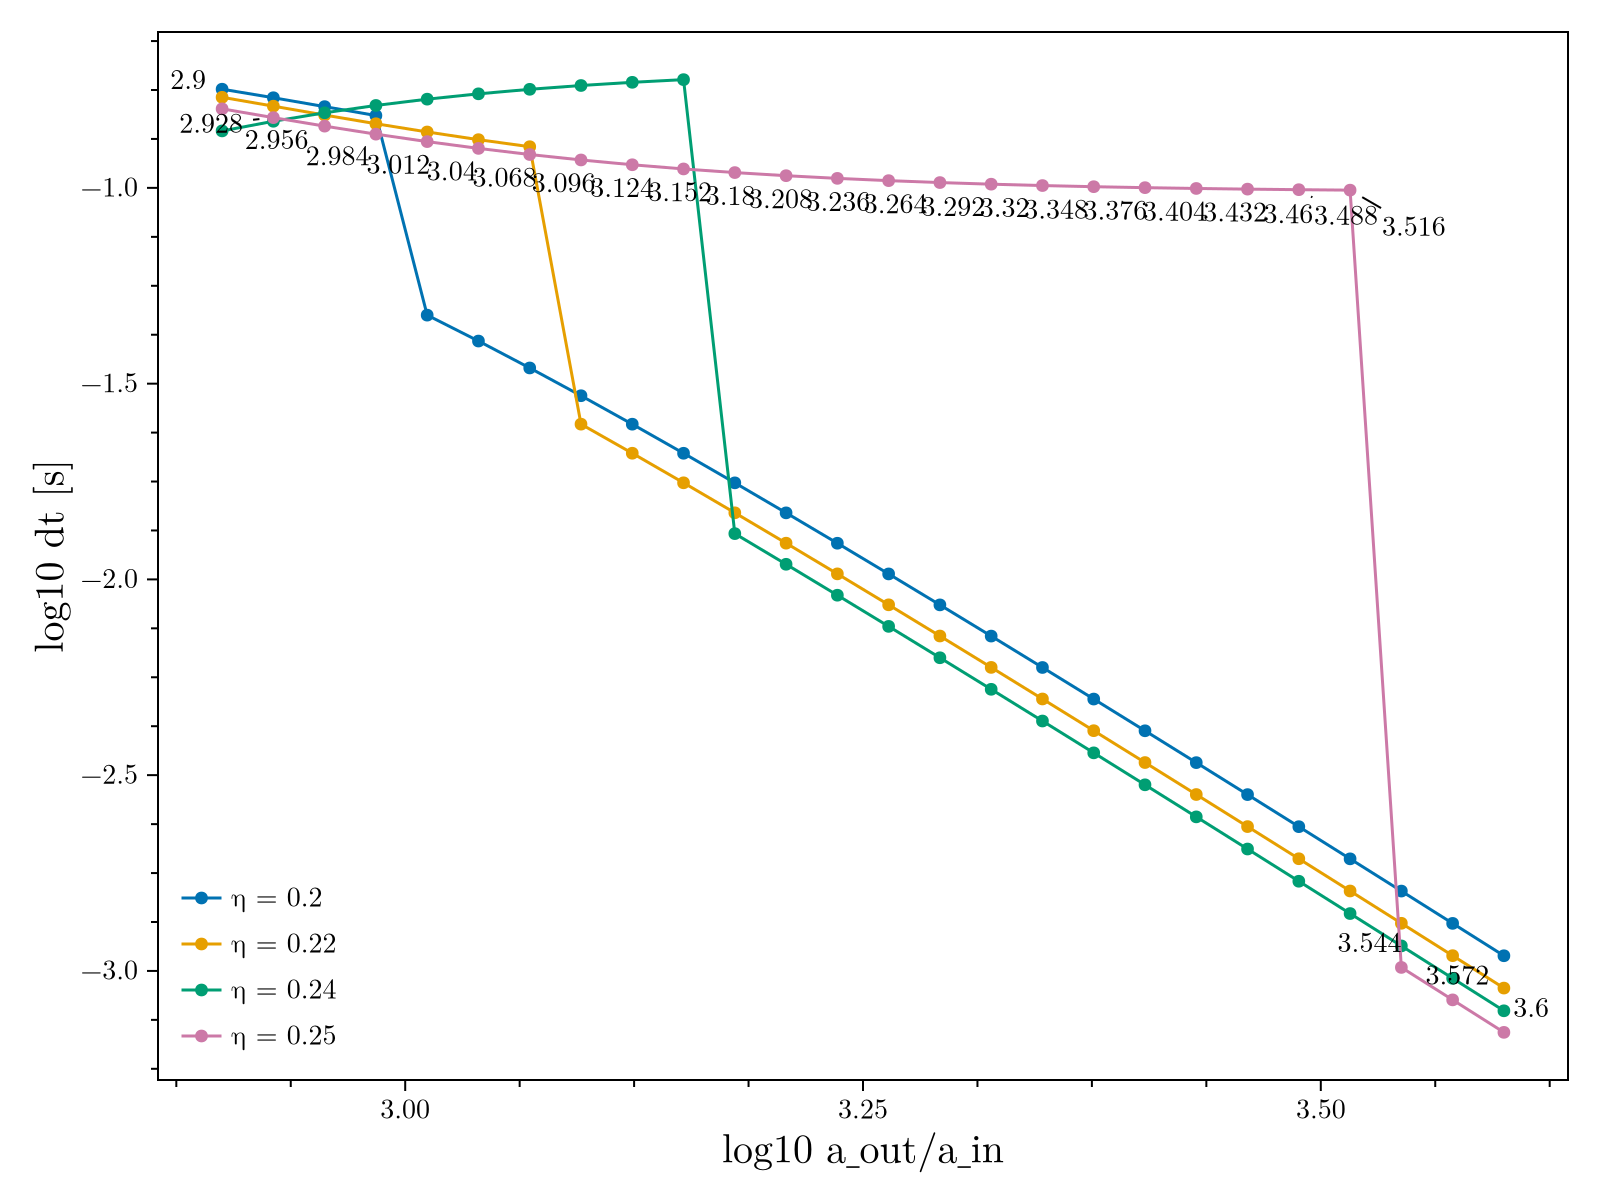

In [62]:
let
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel="log10 a_out/a_in", ylabel="log10 dt [s]")

    
    for eta in (0.2, 0.22, 0.24, 0.25)
        log10_m3s, log10_alphas, dt_max = do_parameter_study(n=25, log10_m3_min=1, log10_m3_max=2, log10_alpha_min=2.9, log10_alpha_max=3.6, eta=eta)
        scatterlines!(ax, log10_alphas, log10.(dt_max[1,:]), label="η = $eta")
        if eta ≈ 0.25
            annotation!(ax, log10_alphas, log10.(dt_max[1,:]), text=string.(round.(log10_alphas, digits=3)))
        end
    end
    
    # hm = heatmap!(log10_m3s, log10_alphas, log10.(dt_max))
    # Colorbar(fig[1, 2], hm, label="max Δt [s]", labelsize=20)
    axislegend(ax, position=:lb)
    fig
end

┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:216
┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:216
┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:216
┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:216


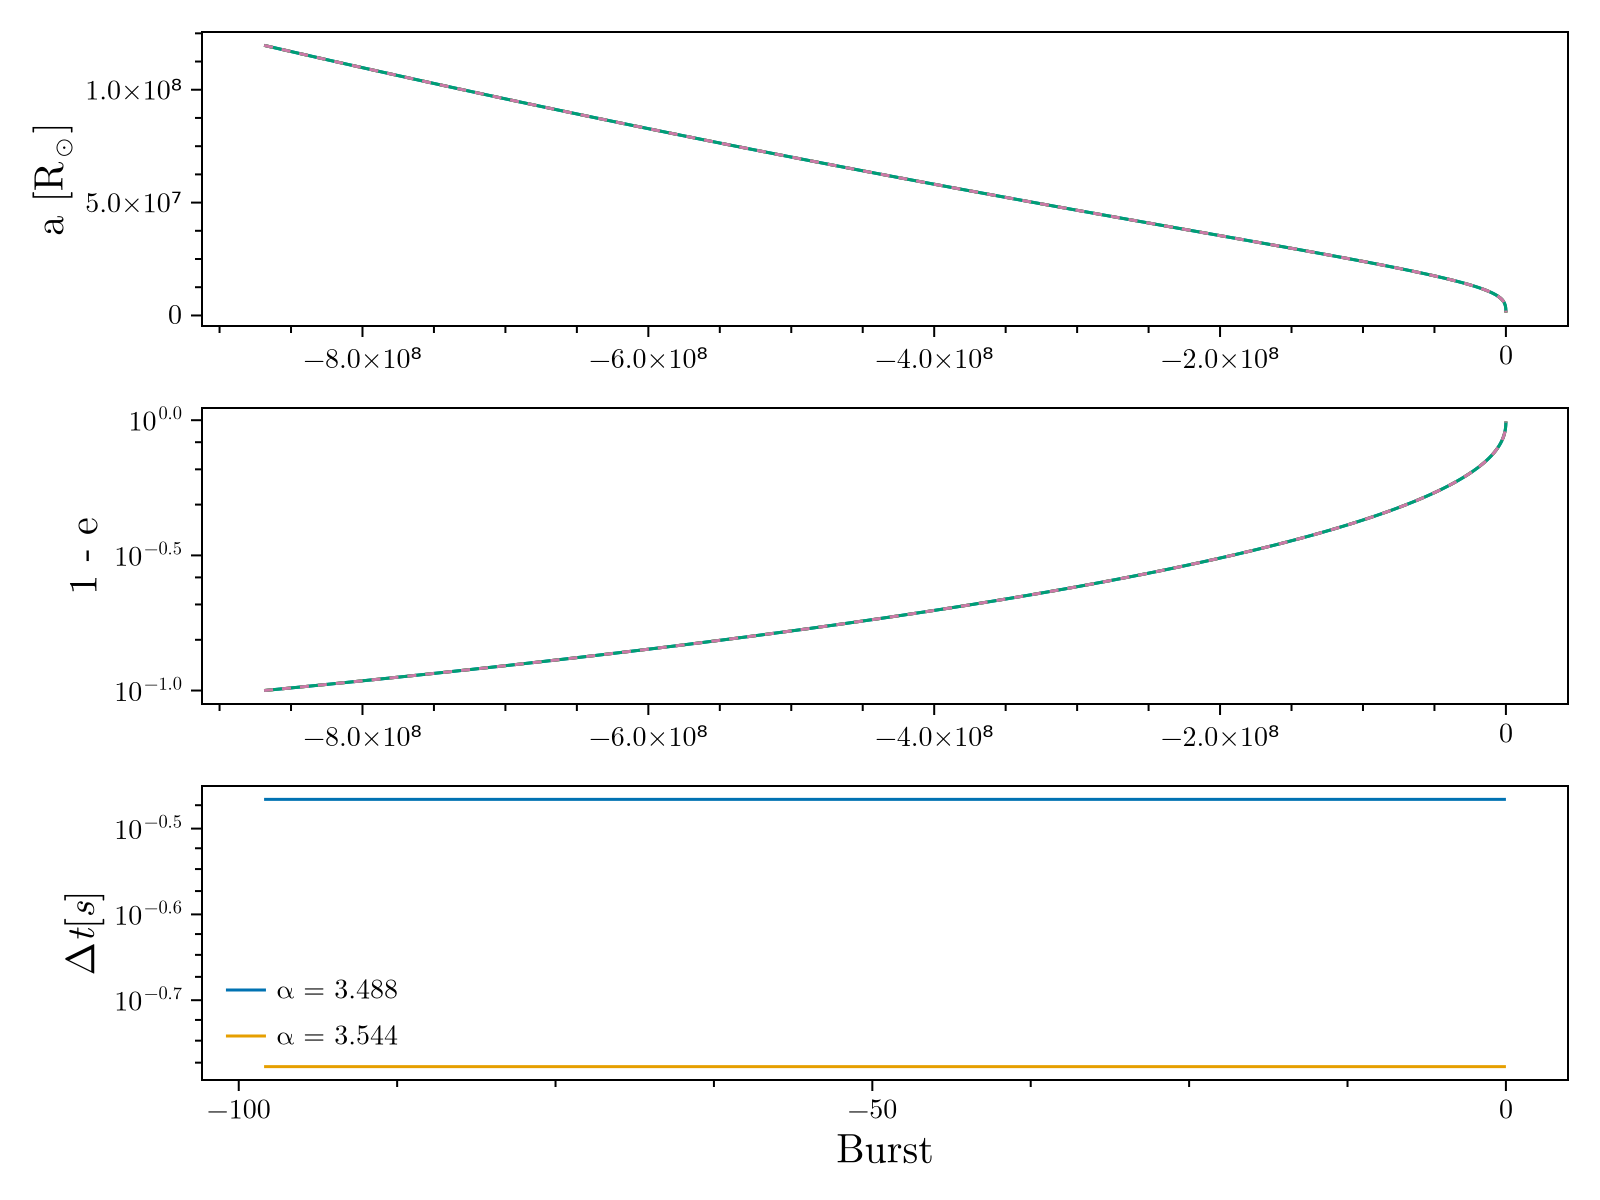

In [22]:
let 
    m12=60
    eta=0.25
    e_in=0.9
    f0=1
    i0=0.0
    e_out=0.0
    N_bursts=50
    a_in = get_a_at_xHz(f0, e_in, m12)
    alphas = (3.488, 3.544)

    # m12=60, eta=0.25, e_in=0.9, f0=1, i0=0.0, e_out=0.0

    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]")
    ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=log10)
    ax_dt = Axis(fig[3, 1], ylabel=L"Δt [s]", xlabel="Burst", yscale=log10)
    for alpha in alphas
        a_out = (10^alpha)*a_in

        m_up, m_p = get_models(m12=m12, e0=e_in, a0=a_in, R3=a_out, i0=i0, m3=10, eta=eta)
        # println(m_p) && break
        evolve!(m_p, 1_000_000, f_GW_max=20, e_min=0.0001, verbose=true, Rmin_threshold=Inf, do_outer_orbit=true)
        evolve!(m_up, 1_000_000, f_GW_max=20, e_min=0.0001, verbose=true, Rmin_threshold=Inf)

        # println(to_seconds(m, m.t[end]))


        t_up = let m = m_up
            # t = to_seconds(m, m.t)
            t = m.t
            t = t .- t[end]
            a = to_meters(m, m.p ./ (1 .- m.e .^ 2))
            e = m.e

            lines!(ax, t, a)
            lines!(ax_e, t, 1 .- e)
            t
        end

        t_p = let m = m_p
            # t = to_seconds(m, m.t)
            t = m.t
            t = t .- t[end]
            a = to_meters(m, m.p ./ (1 .- m.e .^ 2))
            e = m.e
            i = m.ι

            lines!(ax, t, a, linestyle=:dash)
            lines!(ax_e, t, 1 .- e, linestyle=:dash)
            t
        end

        t_up_end = 

        t_up = t_up[1:100]#t_up[end - min(N_bursts, length(t_up) - 1):end]
        t_p = t_p[1:100]#t_p[end - min(N_bursts, length(t_p) - 1):end]
        
        t_up = to_seconds(m_up, t_up)# .- t_up[end])
        t_p = to_seconds(m_p, t_p)# .- t_p[end])

        # t_up = to_seconds(m_up, t_up[t_f_match_idx] - t_up[end])
        # t_p = to_seconds(m_p, t_p[t_p_f_match_idx] - t_p[end])
        
        k = min(length(t_up), length(t_p))
        
        dt = abs.(t_up[1:k-1] .- t_p[1:k-1])
        
        # lines!(ax_dt, abs.(t_up .- t_p))
        # lines!(ax_dt, t_p)
        # vlines!(ax_dt, [to_seconds(m_up, m_up.t[t_f_match_idx] - m_up.t[end]), to_seconds(m_p, m_p.t[t_p_f_match_idx] - m_p.t[end])])
        lines!(ax_dt, -length(dt)+1:0, dt, label="α = $alpha")
        # scatter!(ax_dt, alpha, log10(abs(t_up - t_p)))
    end
    axislegend(ax_dt, position=:lb)
    fig
end

# N-body

In [2]:
using Syzygy, Peaks
using LinearAlgebra: norm

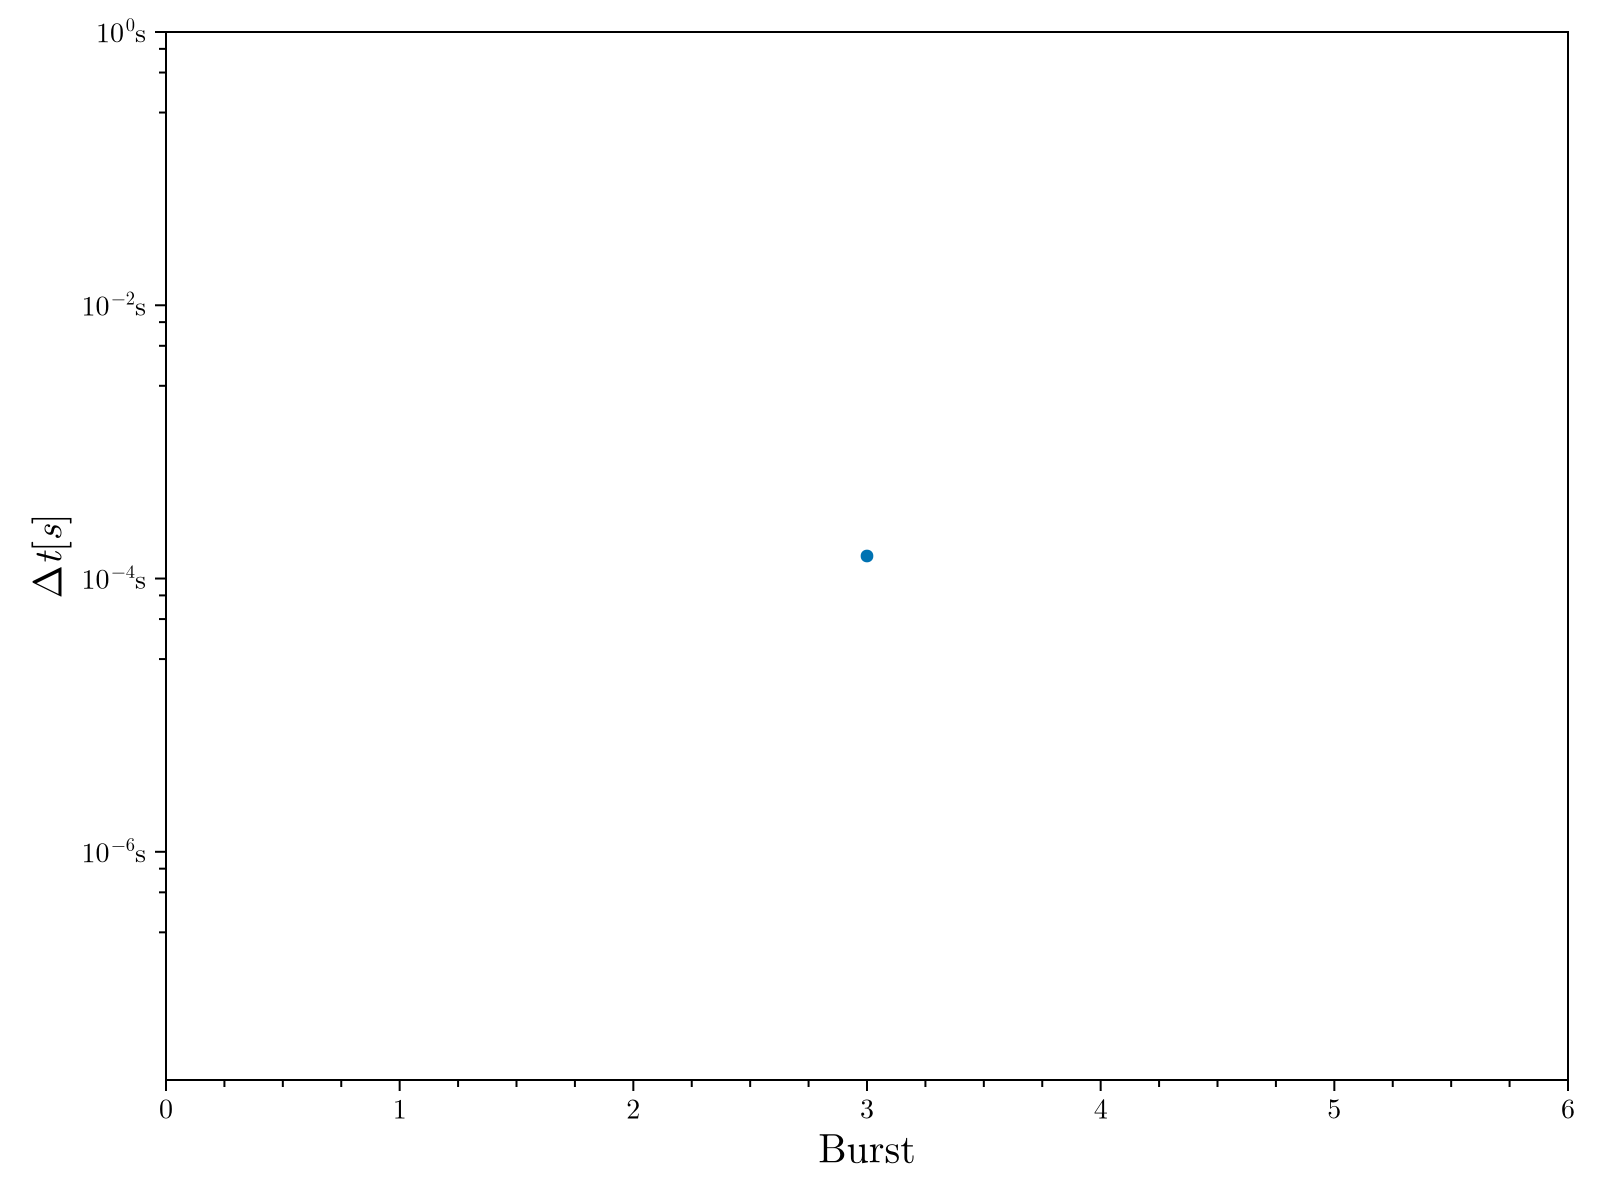

In [ ]:
let 
    m1, m2, m3 = 30Msun, 30Msun, 10Msun
   
    e_in=0.9
    f0=10
    i0=0.0
    e_out=0.0
    N_bursts=50

    a_in = get_a_at_xHz(f0, e_in, ustrip(Msun, m1+m2))*Rsun
  
    alphas= range(3.488, 3.544, length=5)

    fig = Figure()
    # ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]")
    # ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=log10)
    ax_dt = Axis(fig[1, 1], ylabel=L"Δt [s]", xlabel="Burst", yscale=log10)
    tme = time()
    for alpha in alphas
        a_out = (10^alpha)*a_in
        
        m_up = multibodysystem([m1, m2], a=a_in, e=e_in)
        t_up = let m = m_up
            pot = [PureGravitationalPotential(m), PN2p5Potential(m)]
            res = simulate(m, t_sim=10_000, potential=pot, callbacks=[], 
                              max_cpu_time=0.1, alg=Syzygy.ODESolvers.FineRKN5, 
                              abstol=1e-12, reltol=1e-12)
            
            d = let u = Array(res.solution)
                norm.(eachcol(u[4:6,1:2:end-1] .- u[4:6,2:2:end]))
            end

            ids, _ = findminima(d)
            # println(time() - tme)
            res.solution.t[ids] .* m.units.u_time
        end

        m_p = multibodysystem([m1, m2, m3], a=[a_in, a_out], e=[e_in, e_out])
        t_p = let m = m_p
            pot = [PureGravitationalPotential(m), PN2p5Potential(m)]
            res = simulate(m, t_sim=10_000, potential=pot, callbacks=[], 
                              max_cpu_time=0.1, alg=Syzygy.ODESolvers.FineRKN5, 
                              abstol=1e-12, reltol=1e-12)
            
            # println(time() - tme)
            # sol = postprocess(sol)
            # println(time() - tme)
            d = let u = Array(res.solution)
                norm.(eachcol(u[4:6,1:3:end-1] .- u[4:6,2:3:end]))
            end
            ids, _ = findminima(d)
            # println(time() - tme)
            res.solution.t[ids] .* m.units.u_time
        end

        # t_up = t_up[end - min(N_bursts, length(t_up) - 1):end]
        # t_p = t_p[end - min(N_bursts, length(t_p) - 1):end]
        # t_up = t_up .- t_up[end]
        # t_p = t_p .- t_p[end]
        # k = min(length(t_up), length(t_p))
        # dt = abs.(t_up[1:k] .- t_p[1:k])
        k = min(length(t_up), length(t_p))
        t_f_match_idx = 2#findmin(l -> abs(EBT.peak_f_GW(m_up, l) - f_match), 1:length(t_up))[2]
        t_p_f_match_idx = 2#findmin(l -> abs(EBT.peak_f_GW(m_p, l) - f_match), 1:length(t_p))[2]
        t = t_up[t_f_match_idx]# - t_up[k]
        t_p = t_p[t_p_f_match_idx]# - t_p[k]

        # println(m_up.binaries[1].elements.P, " ", t, " ", t_p)
        dt = abs(t - t_p)

        # lines!(ax_dt, -length(dt)+1:0, dt)
        scatter!(ax_dt, alpha, dt)
        # println(time() - tme)
    end
    # println(time() - tme)
    fig
end

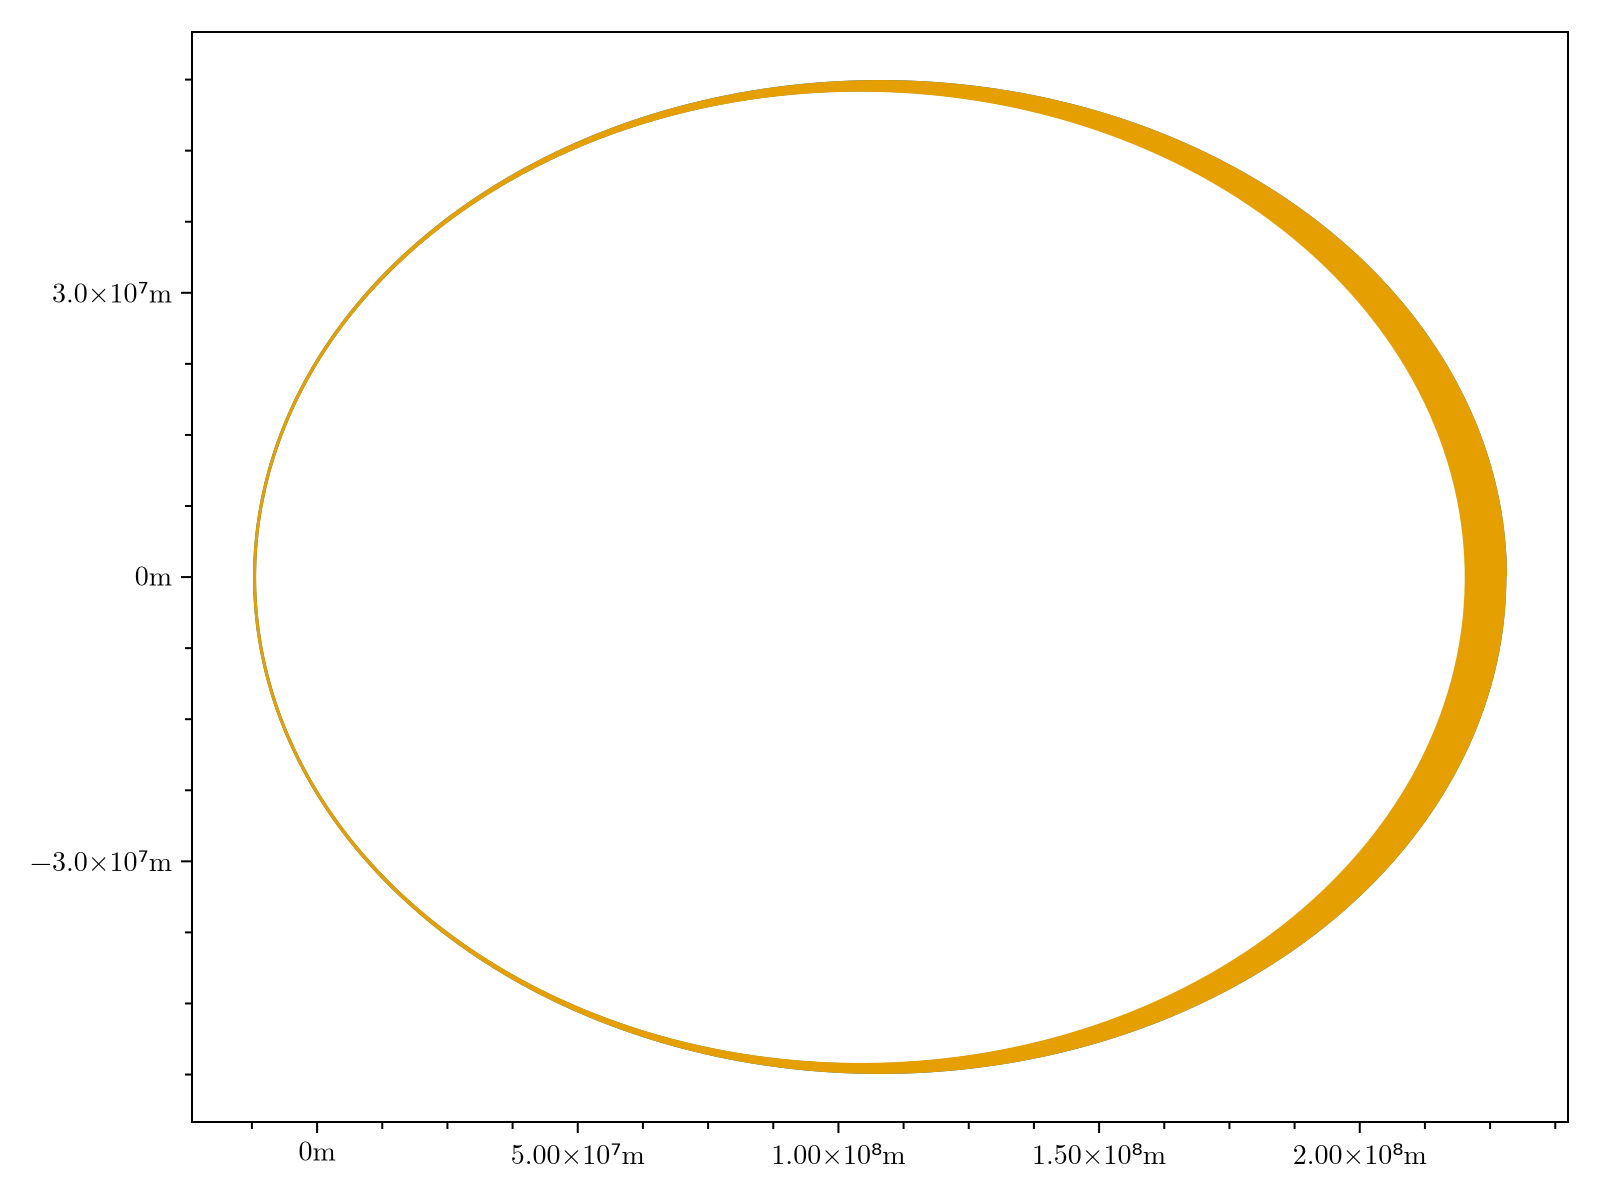

In [11]:
let 
    m1, m2, m3 = 30Msun, 30Msun, 10Msun
   
    e_in=0.9
    f0=1
    i0=0.0
    e_out=0.0
    N_bursts=50

    a_in = get_a_at_xHz(f0, e_in, ustrip(Msun, m1+m2))*Rsun
  
    alphas= range(3.488, 3.544, length=5)

    fig = Figure()
    # ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]")
    # ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=log10)
    ax = Axis(fig[1, 1])
    for alpha in alphas[1:1]
        a_out = (10^alpha)*a_in
        
        m_up = multibodysystem([m1, m2], a=a_in, e=e_in)
        let m = m_up
            pot = [PureGravitationalPotential(m), PN2p5Potential(m)]
            res = simulate(m, t_sim=10_000, potential=pot, callbacks=[], 
                              max_cpu_time=0.1, alg=Syzygy.ODESolvers.FineRKN5, 
                              abstol=1e-12, reltol=1e-12)
            
            r = let u = Array(res.solution)
                (u[4:5,1:2:end-1] .- u[4:5,2:2:end]) .* m.units.u_length
            end
            
            lines!(ax, r[1,:], r[2,:])
        end

        m_p = multibodysystem([m1, m2, m3], a=[a_in, a_out], e=[e_in, e_out])
        let m = m_p
            pot = [PureGravitationalPotential(m), PN2p5Potential(m)]
            res = simulate(m, t_sim=10_000, potential=pot, callbacks=[], 
                              max_cpu_time=0.1, alg=Syzygy.ODESolvers.FineRKN5, 
                              abstol=1e-12, reltol=1e-12)
            

            r = let u = Array(res.solution)
                (u[4:5,1:3:end-1] .- u[4:5,2:3:end]) .* m.units.u_length
            end
            
            lines!(ax, r[1,:], r[2,:])
        end
    end
    fig
end